### **1. Préparation et Exploration du Corpus de Données**

Pour ce projet, nous utilisons le jeu de données **"20 Newsgroups"**, une référence standard dans le domaine du Traitement Automatique du Langage Naturel (NLP).

### Description du Dataset
Ce corpus contient environ 20 000 documents provenant de forums de discussion Usenet, partitionnés (presque uniformément) en 20 groupes thématiques différents.

### Sélection des classes
Afin de construire un modèle de classification pertinent et d'optimiser le temps d'entraînement pour ce mini-projet, nous avons sélectionné un sous-ensemble de **4 catégories** distinctes :

1.  **`sci.med`** : Discussions relatives à la médecine et la santé.
2.  **`sci.space`** : Discussions sur l'astronomie et l'espace.
3.  **`comp.graphics`** : Discussions techniques sur le graphisme informatique.
4.  **`rec.autos`** : Discussions sur l'automobile.

Cette étape consiste à charger les données brutes via la librairie `Scikit-learn`, en séparant l'ensemble d'entraînement (*Train*) et l'ensemble de test (*Test*).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import re
import nltk
from nltk.corpus import stopwords
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
import gradio as gr

# Configuration pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)
nltk.download('stopwords')

print("Bibliothèques importées avec succès.")

c:\Users\mon pc\miniconda3\envs\nlp_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliothèques importées avec succès.


[nltk_data] Downloading package stopwords to C:\Users\mon
[nltk_data]     pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **1. Préparation du corpus de données**

Conformément aux consignes, nous utilisons un jeu de données public pour la classification de documents. Nous avons choisi le dataset **"20 Newsgroups"**, une référence en NLP.

Afin de construire un modèle performant et adapté aux contraintes de temps, nous nous concentrons sur 4 catégories thématiques distinctes :
* **Médecine** (`sci.med`)
* **Espace** (`sci.space`)
* **Graphisme Informatique** (`comp.graphics`)
* **Automobile** (`rec.autos`)

Nous chargeons les données brutes et séparons les étiquettes (labels) des textes.

Chargement des données en cours...

--- Statistiques du Dataset ---
Nombre de documents d'entraînement : 2365
Nombre de documents de test        : 1575
Nombre de classes                  : 4
Classes cibles                     : ['comp.graphics', 'rec.autos', 'sci.med', 'sci.space']


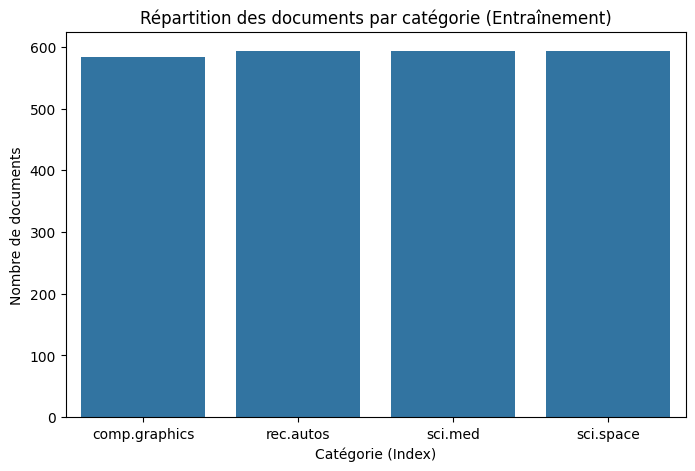


--- Exemple de document brut (Catégorie : comp.graphics) ---
--------------------------------------------------------------------------------
: A very kind soul has mailed me this reply for the bugs in CView.
: Since he isn't in the position to post this himself, he asked me to post
: it for him, but to leave his name out. So here it comes:
: 
: CView has quite a number of bugs.  The one you mention is perhaps the most
:
A stupid question, but what will CView run on and where can I get it? I
am still in need of a GIF viewer for Linux. (Without X-Windows.)
Thanks!
 
...
--------------------------------------------------------------------------------


In [2]:
# Sélection des catégories
categories = ['sci.med', 'sci.space', 'comp.graphics', 'rec.autos']

# Chargement des données
print("Chargement des données en cours...")
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

X_raw_train = newsgroups_train.data
y_raw_train = newsgroups_train.target
X_raw_test = newsgroups_test.data
y_raw_test = newsgroups_test.target
class_names = newsgroups_train.target_names


# Affichage des statistiques
print(f"\n--- Statistiques du Dataset ---")
print(f"Nombre de documents d'entraînement : {len(X_raw_train)}")
print(f"Nombre de documents de test        : {len(X_raw_test)}")
print(f"Nombre de classes                  : {len(class_names)}")
print(f"Classes cibles                     : {class_names}")

# Visualisation de la répartition des classes (Graphique)
plt.figure(figsize=(8, 5))
sns.countplot(x=y_raw_train)
plt.title('Répartition des documents par catégorie (Entraînement)')
plt.xlabel('Catégorie (Index)')
plt.ylabel('Nombre de documents')
plt.xticks(ticks=range(4), labels=class_names)
plt.show()

# Affichage d'un exemple concret de document
print("\n--- Exemple de document brut (Catégorie : " + class_names[y_raw_train[0]] + ") ---")
print("-" * 80)
print(X_raw_train[0][:500] + "...") # Affiche les 500 premiers caractères
print("-" * 80)


### **2. Prétraitement du texte**

Les données textuelles brutes contiennent du "bruit" qui peut gêner l'apprentissage du modèle. Nous appliquons une fonction de nettoyage (`clean_text`) qui réalise les opérations suivantes :
1.  **Minuscules** : Uniformisation du texte (ex: "Table" devient "table").
2.  **Nettoyage Regex** : Suppression de la ponctuation, des nombres et des caractères spéciaux.
3.  **Stopwords** : Suppression des mots vides de sens (comme "the", "is", "a") via la liste fournie par NLTK.

In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Conversion en minuscules
    text = text.lower()
    # Suppression des caractères spéciaux (garde uniquement les lettres)
    text = re.sub(r'[^a-z\s]', '', text)
    # Suppression des stopwords
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    return " ".join(cleaned_words)

# Application du nettoyage
print("Nettoyage des textes...")
X_train_clean = [clean_text(text) for text in X_raw_train]
X_test_clean = [clean_text(text) for text in X_raw_test]

print(f"Exemple brut : {X_raw_train[0][:100]}...")
print(f"Exemple nettoyé : {X_train_clean[0][:100]}...")

Nettoyage des textes...
Exemple brut : : A very kind soul has mailed me this reply for the bugs in CView.
: Since he isn't in the position ...
Exemple nettoyé : kind soul mailed reply bugs cview since isnt position post asked post leave name comes cview quite n...


### **3. Représentation du texte (Word Embeddings)**

Pour que le réseau de neurones puisse traiter le texte, nous devons le convertir en vecteurs numériques. Nous utilisons ici la technique des **Word Embeddings**.

* **Tokenisation** : Nous créons un vocabulaire des 10 000 mots les plus fréquents et associons chaque mot à un index unique.
* **Padding** : Les réseaux de neurones nécessitent des entrées de taille fixe. Nous standardisons tous les documents à une longueur de **200 mots**. Les textes plus courts sont complétés par des zéros.

In [4]:
# Paramètres
VOCAB_SIZE = 10000  # Taille du vocabulaire
MAX_LEN = 200       # Longueur max d'une séquence

# Tokenisation
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

# Conversion texte -> séquences d'entiers
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

# Padding (Remplissage)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Dimension des données d'entraînement : {X_train_pad.shape}")

Dimension des données d'entraînement : (2365, 200)


### **4. Répartition des données en ensembles : train, val et test**

Nous disposons déjà d'un ensemble de test séparé. Cependant, pour surveiller l'entraînement et éviter le surapprentissage (*overfitting*), nous devons créer un **ensemble de validation**.

Nous divisons donc notre ensemble d'entraînement actuel :
* **80%** pour l'entraînement effectif (Train).
* **20%** pour la validation (Val).

In [5]:
# Split Train / Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pad, y_raw_train, test_size=0.2, random_state=42
)

print(f"Données d'entraînement : {X_train.shape}")
print(f"Données de validation  : {X_val.shape}")
print(f"Données de test        : {X_test_pad.shape}")

Données d'entraînement : (1892, 200)
Données de validation  : (473, 200)
Données de test        : (1575, 200)


### **5. Définition de l’architecture d’apprentissage profond**

Nous construisons un modèle basé sur un **CNN 1D (Réseau de Neurones Convolutif)**. Bien que souvent utilisés pour l'image, les CNN sont très efficaces en NLP pour détecter des motifs locaux (groupes de mots).

L'architecture est la suivante :
1.  **Embedding** : Transforme les index de mots en vecteurs denses.
2.  **Conv1D** : Extrait les caractéristiques locales avec 128 filtres.
3.  **GlobalMaxPooling1D** : Réduit la dimension en gardant l'information la plus pertinente.
4.  **Dropout** : Désactive aléatoirement des neurones pour éviter le surapprentissage.
5.  **Dense (Sortie)** : Couche finale avec activation **Softmax** pour prédire la probabilité de chaque classe.

In [6]:
EMBEDDING_DIM = 100

model = Sequential([
    # Couche d'Embedding
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    
    # Couche de Convolution
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    
    # Couche de Pooling
    GlobalMaxPooling1D(),
    
    # Régularisation
    Dropout(0.5),
    
    # Couche Dense intermédiaire
    Dense(64, activation='relu'),
    
    # Couche de sortie (4 classes)
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\mon pc\miniconda3\envs\nlp_project\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### **6. Entraînement du modèle**

Nous lançons l'entraînement sur **10 époques** (cycles complets sur les données). Nous utilisons l'ensemble de validation défini précédemment pour vérifier à chaque étape que le modèle ne mémorise pas simplement les données par cœur.

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.3134 - loss: 1.3676 - val_accuracy: 0.3805 - val_loss: 1.3218
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.6601 - loss: 1.1028 - val_accuracy: 0.6956 - val_loss: 0.9091
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.8768 - loss: 0.5233 - val_accuracy: 0.8478 - val_loss: 0.5106
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.9514 - loss: 0.1917 - val_accuracy: 0.8710 - val_loss: 0.4125
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9715 - loss: 0.0947 - val_accuracy: 0.8668 - val_loss: 0.3822
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.9715 - loss: 0.0735 - val_accuracy: 0.8732 - val_loss: 0.3608
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.9704 - loss: 0.0653 - val_accuracy: 0.8732 - val_loss: 0.3662
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.9752 - loss: 0.0562 - val_accuracy

### **7. Évaluation de la performance du modèle**

Nous évaluons maintenant le modèle sur l'ensemble de **Test** (données qu'il n'a jamais vues).

Nous affichons :
1.  **La précision globale (Accuracy)**.
2.  **Le rapport de classification** : Précision, Rappel et F1-score pour chaque classe.
3.  **La matrice de confusion** : Pour visualiser les erreurs de classification.

Précision sur le Test : 82.29%

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
               precision    recall  f1-score   support

comp.graphics       0.83      0.87      0.85       389
    rec.autos       0.78      0.87      0.82       396
      sci.med       0.84      0.78      0.81       396
    sci.space       0.86      0.77      0.81       394

     accuracy                           0.82      1575
    macro avg       0.83      0.82      0.82      1575
 weighted avg       0.83      0.82      0.82      1575



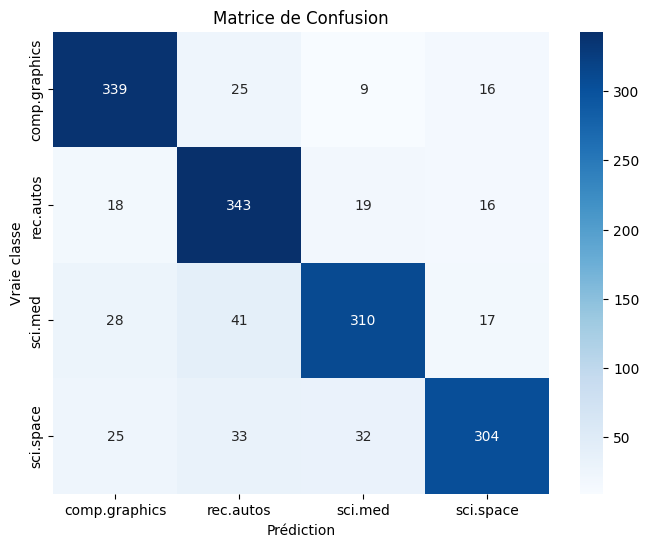

In [8]:
# Prédictions sur le test
loss, accuracy = model.evaluate(X_test_pad, y_raw_test, verbose=0)
print(f"Précision sur le Test : {accuracy * 100:.2f}%\n")

y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Rapport détaillé
print(classification_report(y_raw_test, y_pred, target_names=class_names))

# Matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_raw_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion')
plt.xlabel('Prédiction')
plt.ylabel('Vraie classe')
plt.show()

### **8. Déploiement de la solution développée**

Nous améliorons l'interface de déploiement pour accepter des documents réels sous format **.txt** et **.pdf**.

Nous utilisons la bibliothèque `pypdf` pour l'extraction de contenu. La fonction `classifier_document` vérifie l'extension du fichier :
* Si c'est un **.pdf** : Elle parcourt toutes les pages pour en extraire le texte brut.
* Si c'est un **.txt** : Elle lit le contenu directement.

Le texte extrait passe ensuite par notre pipeline habituel (Nettoyage -> Tokenisation -> Prédiction).

In [9]:
import gradio as gr
from pypdf import PdfReader
import os

def lire_pdf(chemin_fichier):
    """Fonction utilitaire pour extraire le texte d'un PDF"""
    reader = PdfReader(chemin_fichier)
    texte_complet = ""
    for page in reader.pages:
        texte_extrait = page.extract_text()
        if texte_extrait:
            texte_complet += texte_extrait + " "
    return texte_complet

def classifier_document(fichier):
    # Vérification si un fichier est chargé
    if fichier is None:
        return None
    
    # 1. Extraction du texte selon le format
    nom_fichier = fichier.name
    texte_brut = ""
    
    try:
        if nom_fichier.lower().endswith('.pdf'):
            texte_brut = lire_pdf(nom_fichier)
        else:
            # Par défaut, on tente de lire comme un fichier texte
            with open(nom_fichier, 'r', encoding='utf-8') as f:
                texte_brut = f.read()
    except Exception as e:
        return {"Erreur": f"Impossible de lire le fichier. Détails: {str(e)}"}

    # Vérification si du texte a été trouvé
    if not texte_brut.strip():
        return {"Erreur": "Le document semble vide ou illisible (PDF scanné ?)."}

    # 2. Pipeline de Prédiction (Nettoyage -> Tokenisation -> Modèle)
    cleaned_text = clean_text(texte_brut)
    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # 3. Prédiction
    pred_probs = model.predict(padded)[0]
    
    # 4. Résultat
    return {class_names[i]: float(pred_probs[i]) for i in range(len(class_names))}

# Création de l'interface
interface = gr.Interface(
    fn=classifier_document,
    inputs=gr.File(label="Déposez votre rapport (PDF ou TXT)", file_types=[".pdf", ".txt"]),
    outputs=gr.Label(num_top_classes=4, label="Probabilités"),
    title="Système de Classification de Documents",
    description="Analysez vos fichiers PDF ou TXT pour détecter leur thématique (Médecine, Espace, Graphisme, Auto)."
)

# Lancement
interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
